### Loading Libraries

In [36]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile
import geopandas as gpd
from urllib.parse import urlencode


In [2]:
OUTPUT_DIR = "../data/citibike/"

In [3]:
citibike_df = pd.read_csv("../data/citibike/JC/JC2025_Enriched.csv")

### Read and Visualize jersey-city-neighborhoods.geojson data

In [4]:


url = '../data/citibike/JC/jersey-city-neighborhoods.geojson'

# '.shp'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [5]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     object  
 4   neighborhood  53 non-null     object  
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), object(2)
memory usage: 3.6+ KB


In [6]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
jersey_city = jersey_city.to_crs("EPSG:4326")

<Axes: >

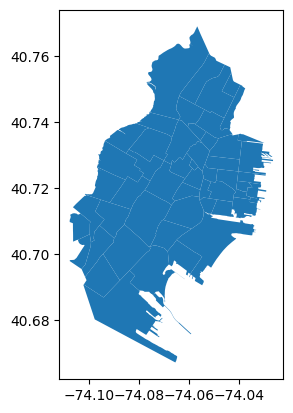

In [8]:
jersey_city.plot()

### Station Level Summary

In [9]:
# station_departures
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

In [10]:
start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

In [11]:
# station_arrivals
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC035,Van Vorst Park,40.718489,-74.047727,arrival
1,124AC7493E82D845,JC014,Columbus Drive,40.718355,-74.038914,arrival
2,1A3BCA838E968327,JC115,Grove St PATH,40.719410,-74.043090,arrival
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,arrival
4,F81BCB97915C6BE6,HB508,Monroe St & 11 St,40.750109,-74.036637,arrival


In [12]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC074,Jersey & 3rd,40.723332,-74.045953,departure
1,124AC7493E82D845,JC074,Jersey & 3rd,40.723332,-74.045953,departure
2,1A3BCA838E968327,JC074,Jersey & 3rd,40.723332,-74.045953,departure
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,departure
4,F81BCB97915C6BE6,JC074,Jersey & 3rd,40.723332,-74.045953,departure


In [23]:
# Cleaning and Aggregating

In [13]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,arrival,6
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,arrival,6
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,arrival,6
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,arrival,6
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,arrival,6


In [14]:
# Convert departure and arrival into separate columns
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,6.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,6.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,6.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,6.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,6.0,0.0


In [24]:
# Rename and Create Final Metrics

In [15]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,259946.0,244456.0,504402.0,-15490.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,146358.0,142558.0,288916.0,-3800.0
2,JC009,Hamilton Park,40.727596,-74.044247,122935.0,122260.0,245195.0,-675.0
3,HB106,River St & Newark St,40.736722,-74.029007,124079.0,121027.0,245106.0,-3052.0
4,JC066,Newport PATH,40.727224,-74.033759,114186.0,113275.0,227461.0,-911.0


In [17]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,259946.0,244456.0,504402.0,-15490.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,146358.0,142558.0,288916.0,-3800.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,122935.0,122260.0,245195.0,-675.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,124079.0,121027.0,245106.0,-3052.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,114186.0,113275.0,227461.0,-911.0,POINT (-74.03376 40.72722)


<Axes: >

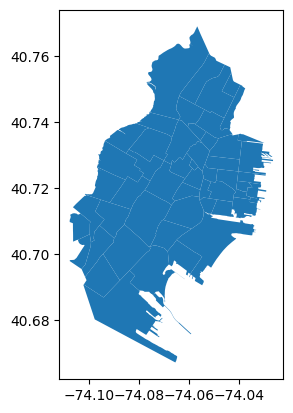

In [18]:
jersey_city.plot()

<Axes: >

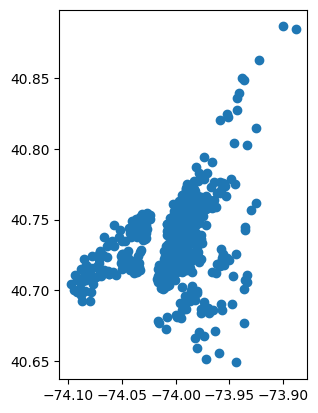

In [19]:
station_gdf.plot()

In [20]:
station_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   station_id        480 non-null    object  
 1   station_name      480 non-null    object  
 2   lat               480 non-null    float64 
 3   lng               480 non-null    float64 
 4   total_arrivals    480 non-null    float64 
 5   total_departures  480 non-null    float64 
 6   total_activity    480 non-null    float64 
 7   net_departures    480 non-null    float64 
 8   geometry          480 non-null    geometry
dtypes: float64(6), geometry(1), object(2)
memory usage: 33.9+ KB


In [21]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     object  
 4   neighborhood  53 non-null     object  
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), object(2)
memory usage: 3.6+ KB


In [22]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,259946.0,244456.0,504402.0,-15490.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,122935.0,122260.0,245195.0,-675.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,114186.0,113275.0,227461.0,-911.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,110771.0,110222.0,220993.0,-549.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,110292.0,110247.0,220539.0,-45.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


### Route-Level Summary

In [25]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
81,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,25336,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5462,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,22891,McGinley Square → Bergen Ave & Sip Ave
8526,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,22226,Grove St PATH → Marin Light Rail
3834,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,20767,Marin Light Rail → Grove St PATH
8540,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,20168,Grove St PATH → Liberty Light Rail


In [26]:
# Top Routes
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
81,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,25336
5462,McGinley Square → Bergen Ave & Sip Ave,22891
8526,Grove St PATH → Marin Light Rail,22226
3834,Marin Light Rail → Grove St PATH,20767
8540,Grove St PATH → Liberty Light Rail,20168
5275,Liberty Light Rail → Grove St PATH,19680
8265,Bergen Ave & Sip Ave → McGinley Square,19049
7978,Hoboken Ave at Monmouth St → Hoboken Terminal ...,18252
4458,Brunswick St → Grove St PATH,17224
3689,Hamilton Park → Grove St PATH,16149


In [27]:
# Top Lines with Folium
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

### Spatial Join Between Stations and Neighborhoods

In [28]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [29]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

In [30]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'geometry'],
      dtype='object')

In [31]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,259946.0,244456.0,504402.0,-15490.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,122935.0,122260.0,245195.0,-675.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,114186.0,113275.0,227461.0,-911.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,110771.0,110222.0,220993.0,-549.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,110292.0,110247.0,220539.0,-45.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [32]:
# How Many Stations Are Inside Jersey City
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 480
Stations inside Jersey City neighborhoods: 78


### Neighborhood-Level Summary

In [33]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,526733.0,540936.0,1067669.0,-14203.0,177944.833333
17,Palus Hook,6,329744.0,328805.0,658549.0,939.0,109758.166667
14,Newport,2,217251.0,217735.0,434986.0,-484.0,217493.000000
10,Journal Square,3,179264.0,177621.0,356885.0,1643.0,118961.666667
4,Hamilton Park,2,173997.0,175114.0,349111.0,-1117.0,174555.500000


In [34]:
# Center Point for the Map
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng


(np.float64(40.734090673586294), np.float64(-74.00151301587097))

In [42]:
# Visualize Each Station as a Point
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

In [43]:
# Merge Neighborhood Metrics Back to Polygons
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,60.0,45.0,105.0,15.0,105.000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,170881.0,170258.0,341139.0,623.0,56856.500
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,33986.0,33456.0,67442.0,530.0,4215.125


In [44]:
# Some neighborhoods may not have Citi Bike stations.

# For those neighborhoods, the activity values will be missing.

# We replace missing values with zero.

activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,60.0,45.0,105.0,105.000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.000
2,Hackensack,0.0,0.0,0.0,0.0,0.000
3,Lafayette,6.0,170881.0,170258.0,341139.0,56856.500
4,Jackson Hill,16.0,33986.0,33456.0,67442.0,4215.125


### Choropleth Map

In [45]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

In [ ]:
# Total Activity by Neighborhood
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

In [47]:
# Choropleth by Number of Stations
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

In [48]:
# Choropleth by Average Activity per Station
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map


In [49]:
# Choropleth by Total Departures
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

In [50]:
# Choropleth by Total Arrivals
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map